# Scratch baselines without SAM — CustomCNN, ResNet18, ViT (3‑channel)
- Chest X-ray Pneumonia vs Normal (Kaggle) — **3-channel (RGB)** scratch baselines.
- We convert grayscale to RGB with `T.Grayscale(3)` so all models receive 3 channels.
- Same preprocessing across models; cosine LR with warmup; early stopping on AUROC.
- Final metrics reported at **0.5** and at a **recall‑first** operating point (target recall = 0.95).


In [5]:
# Clean imports + path setup
import sys, time, warnings
from pathlib import Path
try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)

# Resolve project root (directory containing `src/`)
proj_root = Path.cwd()
for _ in range(5):
    if (proj_root / "src").exists(): break
    proj_root = proj_root.parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))
print("proj_root:", proj_root)

# Project imports
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch
set_seed(42)
DEVICE = get_device()
DEVICE


proj_root: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project


device(type='mps')

In [6]:
# === Paths/config ===
DATASET_DIR = Path("../Data/chest_xray")  # <--- EDIT THIS IF NEEDED

# Keep split identical across notebooks for fair comparison
data_cfg = DataCfg(
    dataset_dir=DATASET_DIR,
    image_size=224,
    batch_size=32,
    num_workers=0,          # 0 on macOS avoids "MallocStackLogging" noise
    pin_memory=True,
    use_stratified_val=True,
    val_ratio=0.20,         # use the same val split you used elsewhere
    gray_to_rgb=True,       # 3-CHANNEL: expand grayscale -> RGB
    compute_norm_stats=True,# compute mean/std from train set (3ch replicated)
    balance_sampler=True
)

train_loader, val_loader, test_loader, info = build_dataloaders(data_cfg, device=DEVICE)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
print("Train counts:", info["train_counts"])

# Class weights: when balance_sampler=True, set None to avoid double-correction
class_weights = None

# Sanity check: confirm 3-channel
xb, yb = next(iter(train_loader))
print("Batch shape:", tuple(xb.shape))  # expect (B, 3, 224, 224)
del xb, yb


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4185 1047 624
Train counts: [1079, 3106]
Batch shape: (32, 3, 224, 224)


In [7]:
# Shared training cfg "envelope" for scratch runs with SAM OFF
scratch_no_sam = TrainCfg(
    epochs=100, patience=15, monitor="va_auroc",
    base_lr=3e-4, weight_decay=0.3,   # ViT defaults; CNN/ResNet override below
    clip_grad_norm=1.0, use_amp=False,
    use_sam=False, sam_rho=0.0,       # SAM OFF
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    target_recall=0.95,
    llrd=False, head_lr_mult=1.0
)


[CustomCNN-scratch-3ch] epoch 01/100  tr_loss=0.4520  val_loss=0.9934  val_acc=0.5769  val_f1=0.6138  val_auroc=0.8328  (no_improve=0)
[CustomCNN-scratch-3ch] epoch 02/100  tr_loss=0.4563  val_loss=0.4275  val_acc=0.7431  val_f1=0.8520  val_auroc=0.9344  (no_improve=0)
[CustomCNN-scratch-3ch] epoch 03/100  tr_loss=0.4218  val_loss=0.3539  val_acc=0.8663  val_f1=0.9062  val_auroc=0.9306  (no_improve=1)
[CustomCNN-scratch-3ch] epoch 04/100  tr_loss=0.3963  val_loss=0.3281  val_acc=0.8290  val_f1=0.8928  val_auroc=0.9360  (no_improve=0)
[CustomCNN-scratch-3ch] epoch 05/100  tr_loss=0.4025  val_loss=0.2736  val_acc=0.8777  val_f1=0.9186  val_auroc=0.9428  (no_improve=0)
[CustomCNN-scratch-3ch] epoch 06/100  tr_loss=0.3779  val_loss=0.2783  val_acc=0.8711  val_f1=0.9138  val_auroc=0.9362  (no_improve=1)
[CustomCNN-scratch-3ch] epoch 07/100  tr_loss=0.3654  val_loss=0.2540  val_acc=0.8892  val_f1=0.9244  val_auroc=0.9471  (no_improve=0)
[CustomCNN-scratch-3ch] epoch 08/100  tr_loss=0.3622  v

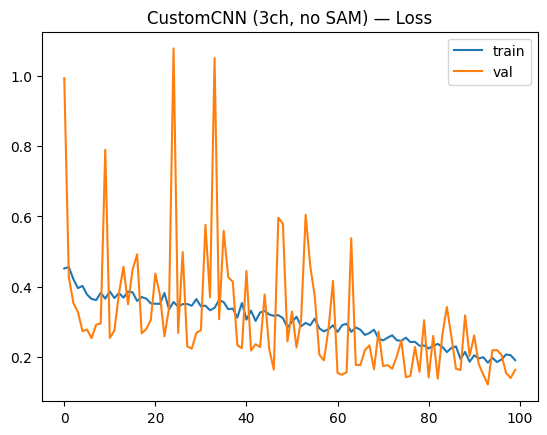

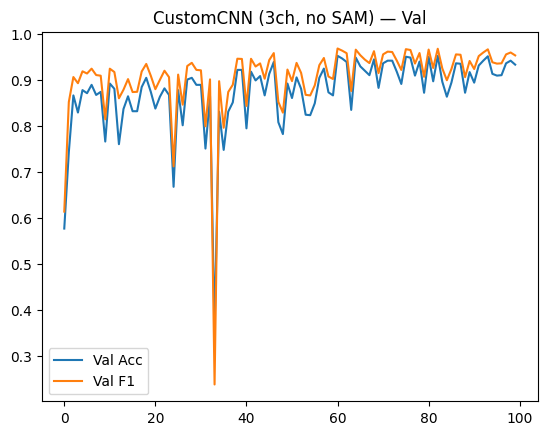

[CustomCNN-3ch @0.5] {'acc': 0.9135, 'precision': 0.9179, 'recall': 0.9462, 'f1': 0.9318, 'auroc': 0.9601, 'thr': 0.5}
[CustomCNN-3ch @Rec] {'acc': 0.8718, 'precision': 0.8399, 'recall': 0.9821, 'f1': 0.9054, 'auroc': 0.9601, 'thr': 0.176}


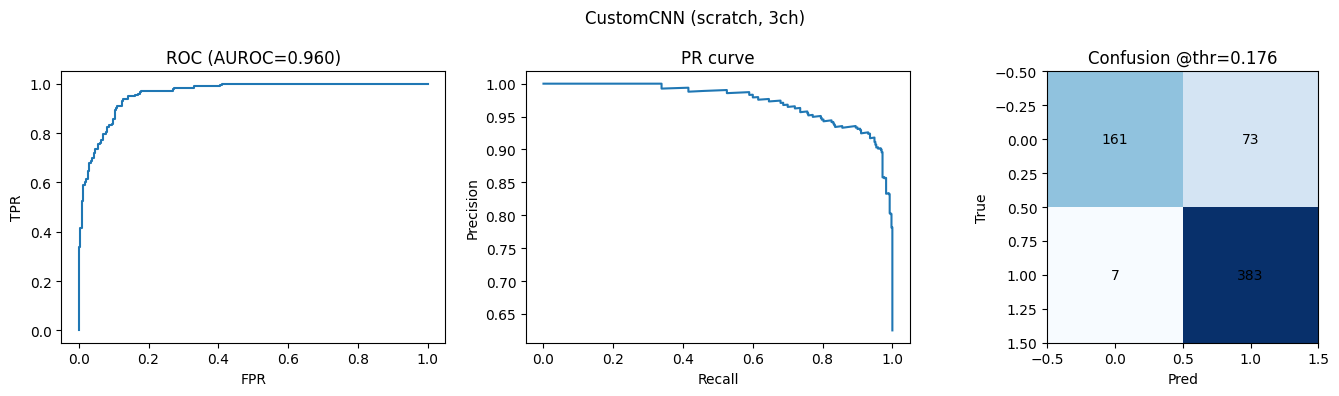

{'summary@0.5': {'acc': 0.9134615384615384,
  'precision': 0.917910447761194,
  'recall': 0.9461538461538461,
  'f1': 0.9318181818181818,
  'auroc': 0.9601030024106947,
  'thr': 0.5},
 'summary@recall': {'acc': 0.8717948717948718,
  'precision': 0.8399122807017544,
  'recall': 0.982051282051282,
  'f1': 0.9054373522458629,
  'auroc': 0.9601030024106947,
  'thr': 0.176},
 'threshold': 0.176,
 'time_sec': 8846.646982908249,
 'params': 481698}

In [8]:
cfg = scratch_no_sam

cnn = build_custom_cnn(in_chans=3, num_classes=2, width=32, dropout=0.0)
t0 = time.time()
cnn_tr, cnn_hist, cnn_time = train_model(
    cnn, train_loader, val_loader, DEVICE, arch="custom_cnn",
    epochs=cfg.epochs, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.0,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="CustomCNN-scratch-3ch"
)
plot_curve(cnn_hist['tr_loss'], cnn_hist['va_loss'], "CustomCNN (3ch, no SAM) — Loss")
plot_two_series(cnn_hist['va_acc'], "Val Acc", cnn_hist['va_f1'], "Val F1", "CustomCNN (3ch, no SAM) — Val")
va = evaluate(cnn_tr, val_loader, DEVICE)
thr, *_ = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(cnn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[CustomCNN-3ch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[CustomCNN-3ch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("CustomCNN (scratch, 3ch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("CustomCNN (scratch, 3ch)", cnn_tr, sum_05, sum_reca, threshold=thr, time_sec=cnn_time)


[ResNet18-scratch-3ch] epoch 01/90  tr_loss=0.4921  val_loss=0.3626  val_acc=0.8195  val_f1=0.8635  val_auroc=0.9652  (no_improve=0)
[ResNet18-scratch-3ch] epoch 02/90  tr_loss=0.5685  val_loss=0.4213  val_acc=0.7947  val_f1=0.8783  val_auroc=0.9556  (no_improve=1)
[ResNet18-scratch-3ch] epoch 03/90  tr_loss=0.4988  val_loss=0.2742  val_acc=0.8586  val_f1=0.8975  val_auroc=0.9600  (no_improve=2)
[ResNet18-scratch-3ch] epoch 04/90  tr_loss=0.4365  val_loss=0.2135  val_acc=0.9293  val_f1=0.9525  val_auroc=0.9737  (no_improve=0)
[ResNet18-scratch-3ch] epoch 05/90  tr_loss=0.3983  val_loss=0.1997  val_acc=0.9198  val_f1=0.9443  val_auroc=0.9762  (no_improve=0)
[ResNet18-scratch-3ch] epoch 06/90  tr_loss=0.3711  val_loss=0.3769  val_acc=0.8606  val_f1=0.8976  val_auroc=0.9719  (no_improve=1)
[ResNet18-scratch-3ch] epoch 07/90  tr_loss=0.3444  val_loss=0.2822  val_acc=0.8797  val_f1=0.9233  val_auroc=0.9567  (no_improve=2)
[ResNet18-scratch-3ch] epoch 08/90  tr_loss=0.3517  val_loss=0.1898  

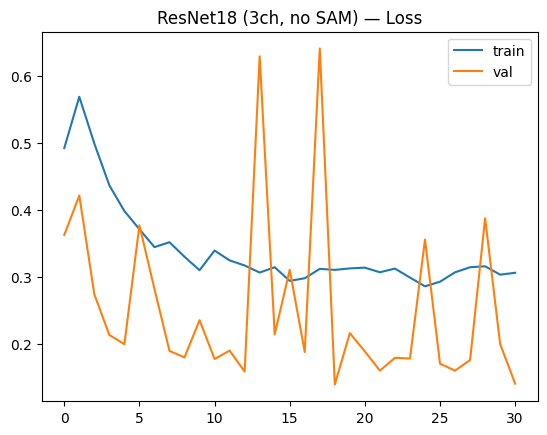

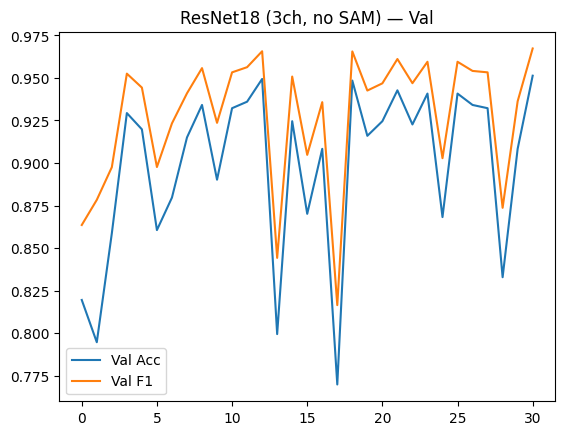

[ResNet18-3ch @0.5] {'acc': 0.867, 'precision': 0.8545, 'recall': 0.9487, 'f1': 0.8991, 'auroc': 0.9242, 'thr': 0.5}
[ResNet18-3ch @Rec] {'acc': 0.8413, 'precision': 0.8063, 'recall': 0.9821, 'f1': 0.8855, 'auroc': 0.9242, 'thr': 0.2205}


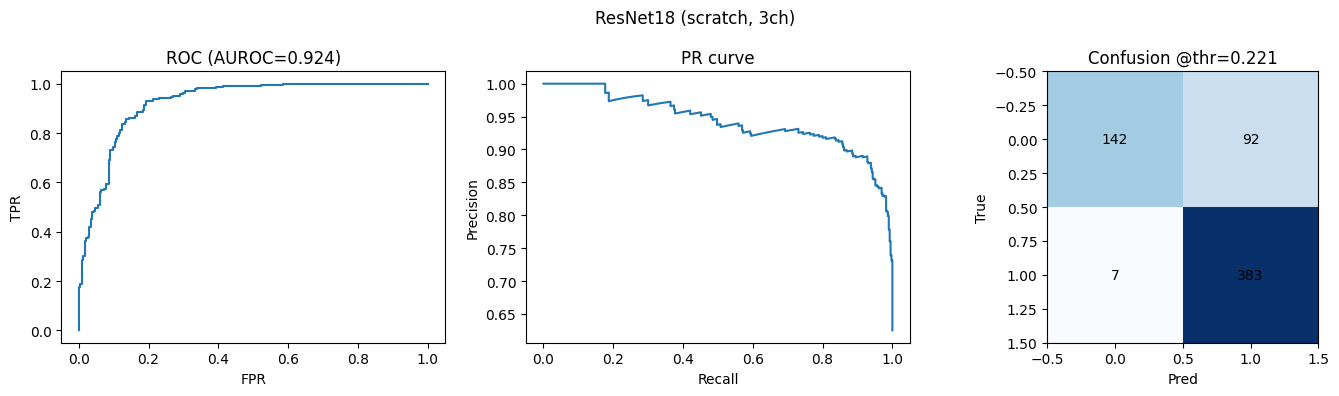

{'summary@0.5': {'acc': 0.8669871794871795,
  'precision': 0.8545034642032333,
  'recall': 0.9487179487179487,
  'f1': 0.8991494532199271,
  'auroc': 0.9241836511067281,
  'thr': 0.5},
 'summary@recall': {'acc': 0.8413461538461539,
  'precision': 0.8063157894736842,
  'recall': 0.982051282051282,
  'f1': 0.8855491329479769,
  'auroc': 0.9241836511067281,
  'thr': 0.2205},
 'threshold': 0.2205,
 'time_sec': 1925.8753793239594,
 'params': 11177538}

In [9]:
rn = build_resnet18(in_chans=3, num_classes=2, pretrained=False, conv_stem=False)
t0 = time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=90, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.0,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=10, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="ResNet18-scratch-3ch"
)
plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 (3ch, no SAM) — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 (3ch, no SAM) — Val")
va = evaluate(rn_tr, val_loader, DEVICE)
thr, *_ = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-3ch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-3ch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (scratch, 3ch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (scratch, 3ch)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-scratch-3ch] epoch 01/120  tr_loss=0.5997  val_loss=0.5089  val_acc=0.7526  val_f1=0.8018  val_auroc=0.9415  (no_improve=0)
[ViT-scratch-3ch] epoch 02/120  tr_loss=0.5539  val_loss=0.3203  val_acc=0.8691  val_f1=0.9061  val_auroc=0.9576  (no_improve=0)
[ViT-scratch-3ch] epoch 03/120  tr_loss=0.5065  val_loss=0.3488  val_acc=0.8472  val_f1=0.8994  val_auroc=0.9105  (no_improve=1)
[ViT-scratch-3ch] epoch 04/120  tr_loss=0.5239  val_loss=0.3772  val_acc=0.8548  val_f1=0.8942  val_auroc=0.9500  (no_improve=2)
[ViT-scratch-3ch] epoch 05/120  tr_loss=0.4618  val_loss=0.4587  val_acc=0.7889  val_f1=0.8357  val_auroc=0.9598  (no_improve=0)
[ViT-scratch-3ch] epoch 06/120  tr_loss=0.4386  val_loss=0.5036  val_acc=0.7240  val_f1=0.7744  val_auroc=0.9444  (no_improve=1)
[ViT-scratch-3ch] epoch 07/120  tr_loss=0.4309  val_loss=0.2437  val_acc=0.9083  val_f1=0.9363  val_auroc=0.9635  (no_improve=0)
[ViT-scratch-3ch] epoch 08/120  tr_loss=0.4488  val_loss=0.2979  val_acc=0.8682  val_f1=0.9055  v

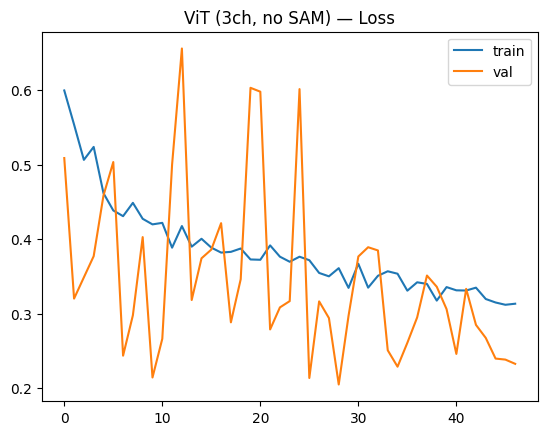

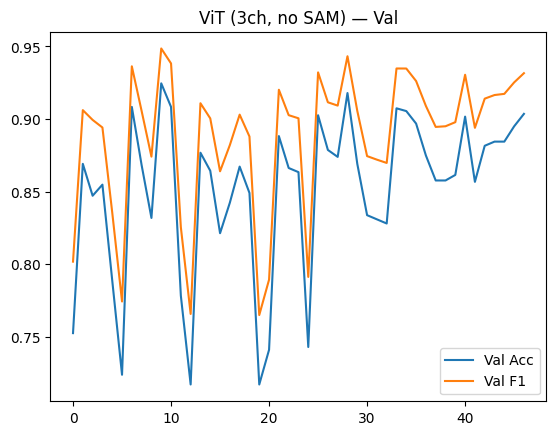

[ViT-3ch @0.5] {'acc': 0.8462, 'precision': 0.9129, 'recall': 0.8333, 'f1': 0.8713, 'auroc': 0.9088, 'thr': 0.5}
[ViT-3ch @Rec] {'acc': 0.7837, 'precision': 0.7555, 'recall': 0.9667, 'f1': 0.8481, 'auroc': 0.9088, 'thr': 0.0925}


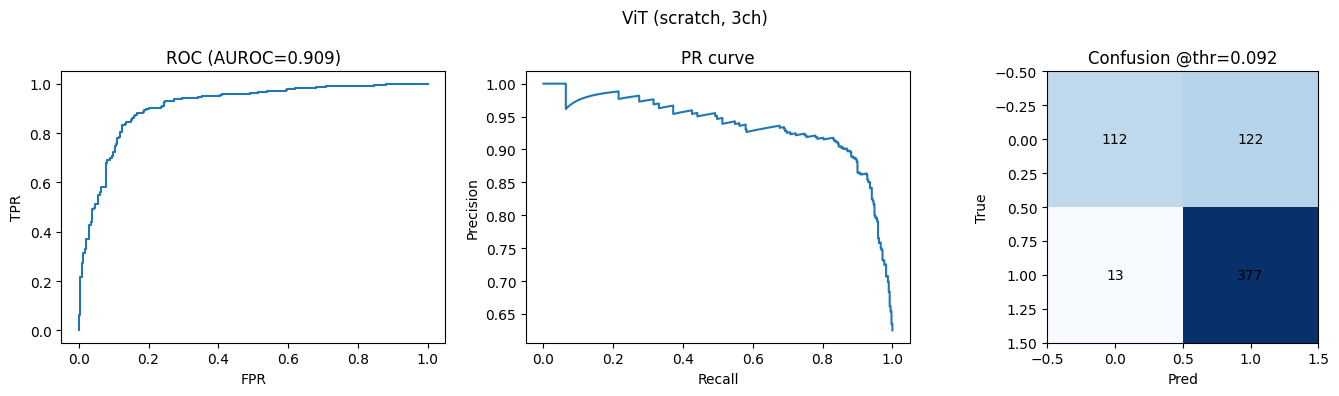

{'summary@0.5': {'acc': 0.8461538461538461,
  'precision': 0.9129213483146067,
  'recall': 0.8333333333333334,
  'f1': 0.871313672922252,
  'auroc': 0.9087990357221127,
  'thr': 0.5},
 'summary@recall': {'acc': 0.7836538461538461,
  'precision': 0.7555110220440882,
  'recall': 0.9666666666666667,
  'f1': 0.8481439820022497,
  'auroc': 0.9087990357221127,
  'thr': 0.0925},
 'threshold': 0.0925,
 'time_sec': 4859.954572916031,
 'params': 21666434}

In [10]:
vit = build_vit_scratch(
    img_size=224, in_chans=3, num_classes=2,
    embed_dim=384, depth=12, heads=6, patch=16, mlp_ratio=4.0, drop=0.1
)
t0 = time.time()
vit_tr, vit_hist, vit_time = train_model(
    vit, train_loader, val_loader, DEVICE, arch="vit",
    epochs=120, base_lr=3e-4, weight_decay=0.3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.0,
    use_cosine=True, warmup_epochs=5, min_lr_mult=0.01,
    monitor="va_auroc", patience=15, clip_grad_norm=1.0,
    class_weights=class_weights, llrd=False, head_lr_mult=1.0, use_amp=False,
    tag="ViT-scratch-3ch"
)
plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT (3ch, no SAM) — Loss")
plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT (3ch, no SAM) — Val")

va = evaluate(vit_tr, val_loader, DEVICE)
thr, *_ = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], scratch_no_sam.target_recall)
te = evaluate(vit_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ViT-3ch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ViT-3ch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ViT (scratch, 3ch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ViT (scratch, 3ch)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [12]:
# === Final comparison tables across all models in this notebook ===
# Builds two tables:
#   (A) Metrics at the threshold that achieves Recall >= 0.95 (from summary@recall)
#   (B) Metrics at fixed threshold = 0.5 (from summary@0.5)
# Requires: from src import result_registry ; each model added via add_result(name, ...)

import math, pandas as pd
from src import result_registry

TARGET_RECALL = 0.95  # what "recall >= 95%" means

if not result_registry:
    raise RuntimeError("result_registry is empty. Make sure you called add_result(...) after each model.")

def _extract_row(model_name: str, rec: dict, which: str):
    """
    which: 'summary@recall' or 'summary@0.5'
    Returns a flat row with common columns.
    """
    s = rec.get(which, {}) or {}
    # Prefer the per-summary 'thr' if present; else fall back to the top-level 'threshold'
    thr = s.get("thr", rec.get("threshold", float("nan")))
    row = {
        "model": model_name,
        "threshold": float(thr) if thr is not None and not isinstance(thr, str) else float("nan"),
        "acc": float(s.get("acc", float("nan"))),
        "precision": float(s.get("precision", float("nan"))),
        "recall": float(s.get("recall", float("nan"))),
        "f1": float(s.get("f1", float("nan"))),
        "auroc": float(s.get("auroc", float("nan"))),
        "params": rec.get("params", None),
        "time_sec": rec.get("time_sec", None),
    }
    return row

# Build both tables from the registry
rows_recall = []
rows_thr05 = []
for name, rec in result_registry.items():
    rows_recall.append(_extract_row(name, rec, "summary@recall"))
    rows_thr05.append(_extract_row(name, rec, "summary@0.5"))

df_recall = pd.DataFrame(rows_recall)
df_thr05  = pd.DataFrame(rows_thr05)

# Add convenience columns and formatting
def _format(df: pd.DataFrame, check_target=False) -> pd.DataFrame:
    df = df.copy()
    # Params in millions; training time in minutes
    if "params" in df:
        df["params (M)"] = df["params"].apply(lambda x: round(x/1e6, 2) if pd.notna(x) else math.nan)
    if "time_sec" in df:
        df["time (min)"] = df["time_sec"].apply(lambda x: round(x/60.0, 1) if pd.notna(x) else math.nan)

    # Human-friendly rounding
    if "threshold" in df: df["threshold"] = df["threshold"].round(3)
    for c in ["acc","precision","recall","f1","auroc"]:
        if c in df:
            df[c] = (df[c] * 100.0).round(2)  # show as %
    # Optional flag: did this row meet the target recall?
    if check_target and "recall" in df:
        df["meets_target(≥95%)"] = df["recall"].apply(lambda r: (pd.notna(r) and r >= TARGET_RECALL*100.0))
    # Reorder columns
    cols = ["model","threshold","acc","precision","recall","f1","auroc","params (M)","time (min)"]
    cols = [c for c in cols if c in df.columns]
    return df[cols]

# Sort by AUROC (desc) as a stable default; change to 'f1' if you prefer
df_recall = df_recall.sort_values(by="auroc", ascending=False).reset_index(drop=True)
df_thr05  = df_thr05.sort_values(by="auroc", ascending=False).reset_index(drop=True)

df_recall = _format(df_recall, check_target=True)
df_thr05  = _format(df_thr05,  check_target=False)

# Display
print("=== Table A — Metrics at threshold chosen to reach Recall ≥ 95% ===")
display(df_recall.style.format({
    "threshold": "{:.3f}",
    "acc": "{:.2f}%", "precision": "{:.2f}%", "recall": "{:.2f}%", "f1": "{:.2f}%", "auroc": "{:.2f}%",
    "params (M)": "{:.2f}", "time (min)": "{:.1f}"
}).set_properties(**{"text-align": "center"}))

print("\n=== Table B — Metrics at fixed threshold = 0.50 ===")
display(df_thr05.style.format({
    "threshold": "{:.3f}",
    "acc": "{:.2f}%", "precision": "{:.2f}%", "recall": "{:.2f}%", "f1": "{:.2f}%", "auroc": "{:.2f}%",
    "params (M)": "{:.2f}", "time (min)": "{:.1f}"
}).set_properties(**{"text-align": "center"}))

# (Optional) Save to CSV alongside the notebook
# df_recall.to_csv("results_table_recall>=95.csv", index=False)
# df_thr05.to_csv("results_table_thr=0.5.csv", index=False)


=== Table A — Metrics at threshold chosen to reach Recall ≥ 95% ===


,model,threshold,acc,precision,recall,f1,auroc,params (M),time (min)
0,"CustomCNN (scratch, 3ch)",0.176,87.18%,83.99%,98.21%,90.54%,96.01%,0.48,147.4
1,"ResNet18 (scratch, 3ch)",0.220,84.13%,80.63%,98.21%,88.55%,92.42%,11.18,32.1
2,"ViT (scratch, 3ch)",0.092,78.37%,75.55%,96.67%,84.81%,90.88%,21.67,81.0



=== Table B — Metrics at fixed threshold = 0.50 ===


,model,threshold,acc,precision,recall,f1,auroc,params (M),time (min)
0,"CustomCNN (scratch, 3ch)",0.500,91.35%,91.79%,94.62%,93.18%,96.01%,0.48,147.4
1,"ResNet18 (scratch, 3ch)",0.500,86.70%,85.45%,94.87%,89.91%,92.42%,11.18,32.1
2,"ViT (scratch, 3ch)",0.500,84.62%,91.29%,83.33%,87.13%,90.88%,21.67,81.0
